## Задача 2.

Исходные данные: стохастическая матрица переходов цепи Маркова согласно варианту 69 (10 вариант 4й группы).

Реализация поставленной задачи:

0. загрузка матрицы переходов, необходимые проверки;
1. построение графа цепи Маркова;
2. ручное выделение классов существенных и несущественных состояний с программной проверкой;
3. перенумерация состояний так, чтобы классы шли смежными блоками;
4. вычисление предельных распределений для всех классов существенных состояний;
5. построение предельной стохастической матрицы переходов без возведения полной матрицы в степень;
6. имитационное моделирование: серия траекторий, частоты посещений и иллюстративные графики переключений.

Необходимая теория.
- Матрица переходов $P=(p_{ij})$ **строго стохастична по строкам**:
  $\sum_j p_{ij} = 1$, $p_{ij} \ge 0$.
- Состояние $i$ называется **существенным**, если из любого достижимого из $i$ состояния вероятность вернуться в $i$ положительна.
- Существенные состояния образуют **замкнутые классы** (из класса нельзя уйти навсегда). Остальные состояния **несущественные (транзиентные)**.

### Загрузка матрицы переходов и базовые проверки

Обозначим через $P$ матрицу переходов размера $15\times 15$ из файла `data_var69.csv`.

Проверим:
- размеры матрицы;
- что суммы по строкам равны 1 (с точностью вычислений).

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["axes.grid"] = True

# Для воспроизводимости имитации
rng = np.random.default_rng(42)

csv_path = "data_var69.csv"
P_df = pd.read_csv(csv_path, header=None)
P = P_df.values

n = P.shape[0]
print("Размер матрицы P:", P.shape)
print("Матрица переходов P:\n", P)

row_sums = P.sum(axis=1)
print("\nСуммы по строкам:", row_sums)
print("Минимальная сумма:", row_sums.min())
print("Максимальная сумма:", row_sums.max())

if np.allclose(row_sums, 1.0):
    print("\nМатрица P является стохастической по строкам.")
else:
    print("\nВНИМАНИЕ: матрица не строго стохастическая по строкам!")

Размер матрицы P: (15, 15)
Матрица переходов P:
 [[0.33 0.   0.   0.28 0.   0.   0.   0.   0.39 0.   0.   0.   0.   0.
  0.  ]
 [0.   0.17 0.   0.   0.   0.   0.23 0.   0.   0.   0.   0.16 0.18 0.
  0.26]
 [0.   0.   0.12 0.   0.36 0.   0.   0.52 0.   0.   0.   0.   0.   0.
  0.  ]
 [0.76 0.   0.   0.12 0.   0.   0.   0.   0.12 0.   0.   0.   0.   0.
  0.  ]
 [0.   0.   0.36 0.   0.12 0.   0.   0.4  0.   0.   0.   0.   0.   0.12
  0.  ]
 [0.   0.   0.   0.   0.   0.24 0.   0.   0.   0.   0.4  0.   0.   0.
  0.36]
 [0.   0.16 0.29 0.   0.   0.   0.18 0.   0.   0.   0.   0.17 0.2  0.
  0.  ]
 [0.   0.   0.25 0.   0.26 0.   0.   0.3  0.   0.   0.   0.   0.   0.19
  0.  ]
 [0.76 0.   0.   0.12 0.   0.   0.   0.   0.12 0.   0.   0.   0.   0.
  0.  ]
 [0.   0.   0.   0.   0.   0.24 0.   0.   0.   0.12 0.52 0.   0.   0.
  0.12]
 [0.   0.   0.   0.   0.   0.28 0.   0.   0.   0.22 0.24 0.   0.   0.
  0.26]
 [0.   0.15 0.   0.   0.   0.   0.28 0.   0.   0.   0.   0.22 0.35 0.
  0.  ]
 [0.   0.2 

### 1. Построение графа цепи Маркова

Граф цепи Маркова — ориентированный граф, в котором:
- **вершины** соответствуют состояниям $S_1,\dots,S_{15}$;
- **дуга** $S_i \to S_j$ проводится, если $p_{ij} > 0$;
- вес дуги равен вероятности перехода $p_{ij}$.

Построим граф при помощи `networkx` и визуализируем его.

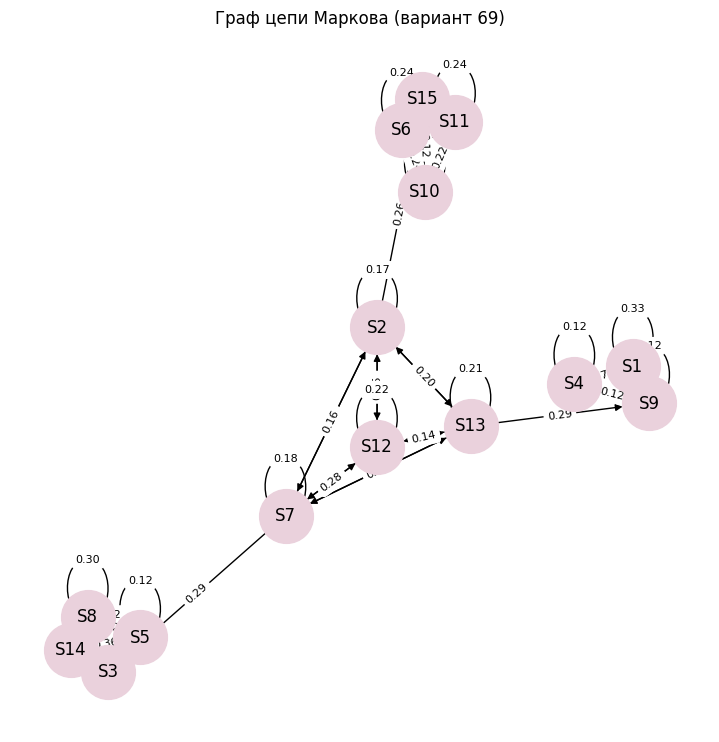

In [12]:
states = [f"S{i+1}" for i in range(n)]

G = nx.DiGraph()
G.add_nodes_from(states)

for i in range(n):
    for j in range(n):
        if P[i, j] > 0:
            G.add_edge(states[i], states[j], weight=P[i, j])

plt.figure(figsize=(7, 7))
pos = nx.spring_layout(G, seed=1)
# pos = nx.kamada_kawai_layout(G, scale=3)
nx.draw(G, pos, with_labels=True, node_size=1500, node_color="#EAD1DC", arrows=True)
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
plt.title("Граф цепи Маркова (вариант 69)")
plt.axis("off")
plt.show()

### 2. Классы существенных и несущественных состояний

По матрице $P$ (и по графу) были вручную выделены классы коммуникативности.

- Из строк 1, 4, 9 видно, что переходы осуществляются только между состояниями $1,4,9$ (и в самих себя).
  Из этих состояний **нельзя выйти наружу**, поэтому класс $C_1 = \{1,4,9\}$ — **замкнутый существенный класс**.
- Аналогично строки 3, 5, 8, 14 образуют замкнутый класс $C_2 = \{3,5,8,14\}$ (переходы только внутри этого набора).
- Строки 6, 10, 11, 15 дают замкнутый класс $C_3 = \{6,10,11,15\}$.
- Состояния $2,7,12,13$ переходят как между собой, так и **уходят** в один из существенных классов (например, 2 переходит в 15; 7 — в 3; 13 — в 9 и т.д.).
- Обратно из классов $C_1,C_2,C_3$ в $2,7,12,13$ переходов нет. Значит, класс $T=\{2,7,12,13\}$ — **несущественный (транзиентный)**.

Итоговая классификация состояний:
- **Несущественный класс (транзиентный)**: $T = \{2,7,12,13\}$.
- **Существенные замкнутые классы**:
  - $C_1 = \{1,4,9\}$,
  - $C_2 = \{3,5,8,14\}$,
  - $C_3 = \{6,10,11,15\}$.

Для проверки выполним то же самое программно через сильносвязные компоненты графа.

In [13]:
# Программная проверка классов через сильносвязные компоненты
sccs = list(nx.strongly_connected_components(G))
sccs_states = [sorted(list(comp), key=lambda s: int(s[1:])) for comp in sccs]
sccs_states

[['S1', 'S4', 'S9'],
 ['S3', 'S5', 'S8', 'S14'],
 ['S6', 'S10', 'S11', 'S15'],
 ['S2', 'S7', 'S12', 'S13']]

Теперь отметим, какие из компонент являются **замкнутыми** (из них нет дуг наружу) и какие — нет. Замкнутые сильносвязные компоненты и есть классы существенных состояний, остальные — классы несущественных состояний.

In [14]:
def is_closed_class(node_set):
    node_set = set(node_set)
    for u in node_set:
        for v in G.successors(u):
            if v not in node_set:
                return False
    return True

closed_classes = []
transient_classes = []

for comp in sccs_states:
    if is_closed_class(comp):
        closed_classes.append(comp)
    else:
        transient_classes.append(comp)

print("Замкнутые классы (существенные):", closed_classes)
print("Классы с выходом (несущественные):", transient_classes)

Замкнутые классы (существенные): [['S1', 'S4', 'S9'], ['S3', 'S5', 'S8', 'S14'], ['S6', 'S10', 'S11', 'S15']]
Классы с выходом (несущественные): [['S2', 'S7', 'S12', 'S13']]


### 3. Перенумерация состояний

-> так, чтобы несущественные состояния и состояния из каждого класса существенных состояний были идентифицированы смежными номерами.

Перенумеруем состояния так, чтобы:
- сначала шёл **класс несущественных состояний** $T=\{2,7,12,13\}$;
- затем подряд шли **существенные классы** $C_1, C_2, C_3$.

Выберем следующую новую нумерацию:
- новые состояния 1–4: старые $[2,7,12,13]$ (класс $T$);
- новые состояния 5–7: старые $[1,4,9]$ (класс $C_1$);
- новые состояния 8–11: старые $[3,5,8,14]$ (класс $C_2$);
- новые состояния 12–15: старые $[6,10,11,15]$ (класс $C_3$).

Построим перенумерованную матрицу $\tilde P$ по этой перестановке.

In [15]:
# Перестановка: new_index -> old_index
perm_old = np.array([2, 7, 12, 13,   # T
                     1, 4, 9,        # C1
                     3, 5, 8, 14,    # C2
                     6, 10, 11, 15]) # C3
perm_old -= 1  # перейти к 0-базным индексам

# Обратная перестановка: old_index -> new_index
inv_perm = np.empty_like(perm_old)
for new_idx, old_idx in enumerate(perm_old):
    inv_perm[old_idx] = new_idx

P_perm = P[perm_old][:, perm_old]
P_perm

array([[0.17, 0.23, 0.16, 0.18, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.26],
       [0.16, 0.18, 0.17, 0.2 , 0.  , 0.  , 0.  , 0.29, 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  ],
       [0.15, 0.28, 0.22, 0.35, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  ],
       [0.2 , 0.16, 0.14, 0.21, 0.  , 0.  , 0.29, 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.33, 0.28, 0.39, 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.76, 0.12, 0.12, 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.76, 0.12, 0.12, 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.12, 0.36, 0.52, 0.  ,
        0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.36, 0.12, 0.4 , 0.12,
        0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  ,

В новой нумерации матрица $\tilde P$ имеет блочную структуру вида
$$
\tilde P = \begin{pmatrix}
Q & R \\
0 & J
\end{pmatrix},
$$
где:
- $Q$ — переходы внутри транзиентного класса $T$ (первые 4 строки/столбца),
- $R$ — переходы из транзиентных состояний в существенные,
- $J$ — блочно-диагональная матрица, соответствующая классам $C_1, C_2, C_3$.

### 4. Предельные распределения для существенных классов

Для каждого замкнутого класса $C_k$ с матрицей переходов $P^{(k)}$ (ограниченной на состояния класса) существует **стационарное распределение** $\pi^{(k)}$:
$$
\pi^{(k)} P^{(k)} = \pi^{(k)}, \quad \sum_j \pi^{(k)}_j = 1.
$$
В пределе **любой старт внутри класса** приводит к одному и тому же распределению по состояниям класса — именно $\pi^{(k)}$.

Найдём $\pi^{(k)}$ для классов $C_1, C_2, C_3$ численно (через собственный вектор с собственным значением 1 или через решение линейной системы).

In [16]:
def stationary_distribution(P_sub, eps=1e-14):
    """ 
    Стационарное распределение π для замкнутого класса.
    Решаем систему (P^T - I) π = 0 с ограничением sum(π)=1.
    """
    m = P_sub.shape[0]
    A = (P_sub.T - np.eye(m)).copy()
    b = np.zeros(m)

    # Заменяем одно уравнение на нормировку
    A[-1, :] = 1.0
    b[-1] = 1.0

    pi = np.linalg.solve(A, b)

    # Чистим численные артефакты: очень маленькие отрицательные -> 0
    pi[np.abs(pi) < eps] = 0.0
    if (pi < 0).any():
        # если из-за чисел появились минусы, клипаем и перенормируем
        pi = np.clip(pi, 0.0, None)
    s = pi.sum()
    if s <= 0:
        raise ValueError("Не удалось найти стационарное распределение")
    return pi / s

# Выделим блоки для классов C1, C2, C3 в НОВОЙ нумерации
idx_T = np.arange(0, 4)
idx_C1 = np.arange(4, 7)
idx_C2 = np.arange(7, 11)
idx_C3 = np.arange(11, 15)

P_C1 = P_perm[np.ix_(idx_C1, idx_C1)]
P_C2 = P_perm[np.ix_(idx_C2, idx_C2)]
P_C3 = P_perm[np.ix_(idx_C3, idx_C3)]

pi_C1 = stationary_distribution(P_C1)
pi_C2 = stationary_distribution(P_C2)
pi_C3 = stationary_distribution(P_C3)

print("Стационарное распределение в классе C1 (новая нумерация 5–7):", pi_C1)
print("Стационарное распределение в классе C2 (новая нумерация 8–11):", pi_C2)
print("Стационарное распределение в классе C3 (новая нумерация 12–15):", pi_C3)

Стационарное распределение в классе C1 (новая нумерация 5–7): [0.5315 0.205  0.2635]
Стационарное распределение в классе C2 (новая нумерация 8–11): [0.2221 0.2571 0.4117 0.1091]
Стационарное распределение в классе C3 (новая нумерация 12–15): [0.2569 0.1056 0.4225 0.215 ]


### 5. Предельная стохастическая матрица переходов

Не рассматривая степени **полной** матрицы $P$, используем блочную структуру $\tilde P$:
$$
\tilde P = \begin{pmatrix}
Q & R \\
0 & J
\end{pmatrix}, \quad J = \operatorname{diag}(P^{(1)}, P^{(2)}, P^{(3)}).
$$

- Для замкнутых классов $C_k$ предельная матрица внутри класса имеет вид: каждая строка равна $\pi^{(k)}$.
- Для транзиентных состояний предельное распределение — смесь стационарных распределений классов с весами, равными **вероятностям поглощения** в каждый класс.

Обозначим $Q$ — подматрица $4\times 4$ для транзиентного класса $T$ (первые 4 состояния новой нумерации),
$R^{(k)}$ — вектор вероятностей за один шаг попасть из транзиентных состояний в класс $C_k$ (сумма соответствующих столбцов).

Для каждого класса $C_k$ решаем систему на **вероятности поглощения** $h^{(k)} \in \mathbb{R}^4$:
$$
h^{(k)} = Q h^{(k)} + r^{(k)} \quad \Rightarrow \quad (I - Q) h^{(k)} = r^{(k)},
$$
где $r^{(k)}$ — вектор вероятностей за **один шаг** выйти из транзиентного состояния в класс $C_k$.

Тогда для транзиентного состояния $i$ и состояния $j$ внутри класса $C_k$ предельная вероятность равна
$$
\lim_{n\to\infty} p_{ij}^{(n)} = h_i^{(k)} \cdot \pi_j^{(k)}.
$$
Построим полную предельную матрицу $\tilde P^{(\infty)}$ в новой нумерации, а затем вернёмся к исходной нумерации.

In [17]:
# Блоки Q и R в новой нумерации
Q = P_perm[np.ix_(idx_T, idx_T)]
R_full = P_perm[np.ix_(idx_T, np.arange(4, 15))]  # переходы из T во все существенные состояния

I_Q = np.eye(Q.shape[0])
N_fund = np.linalg.inv(I_Q - Q)  # фундаментальная матрица (не для всей P, а только для транзиентного блока)

# Векторы r^(k): суммарная вероятность за один шаг из T попасть в любой элемент класса Ck
def r_vector_for_class(idx_class):
    # Индексы внутри полной P_perm
    idx = np.array(idx_class)
    return P_perm[np.ix_(idx_T, idx)].sum(axis=1)

r_C1 = r_vector_for_class(idx_C1)
r_C2 = r_vector_for_class(idx_C2)
r_C3 = r_vector_for_class(idx_C3)

# Решаем (I - Q) h^(k) = r^(k)
h_C1 = np.linalg.solve(I_Q - Q, r_C1)
h_C2 = np.linalg.solve(I_Q - Q, r_C2)
h_C3 = np.linalg.solve(I_Q - Q, r_C3)

print("Вероятности поглощения из T в C1:", h_C1)
print("Вероятности поглощения из T в C2:", h_C2)
print("Вероятности поглощения из T в C3:", h_C3)
print("Сумма по классам (должна быть ~1):", (h_C1 + h_C2 + h_C3))

# Формируем предельную матрицу в новой нумерации
P_lim_perm = np.zeros_like(P_perm)

# Строки для транзиентных состояний: смеси стационарных распределений классов
for i in range(len(idx_T)):
    # вклад от каждого класса в соответствующие блоки столбцов
    P_lim_perm[i, idx_C1] = h_C1[i] * pi_C1
    P_lim_perm[i, idx_C2] = h_C2[i] * pi_C2
    P_lim_perm[i, idx_C3] = h_C3[i] * pi_C3

# Строки для существенных состояний: внутри своего класса — стационарное распределение, вне класса — нули
for idx_class, pi_class in [(idx_C1, pi_C1), (idx_C2, pi_C2), (idx_C3, pi_C3)]:
    for i in idx_class:
        P_lim_perm[i, idx_class] = pi_class

print("\nПроверка стохастичности предельной матрицы (новая нумерация):")
print(P_lim_perm.sum(axis=1))

# Вернёмся к исходной нумерации состояний
P_lim_original = P_lim_perm[inv_perm][:, inv_perm]
P_lim_original

Вероятности поглощения из T в C1: [0.2774 0.2762 0.4061 0.5652]
Вероятности поглощения из T в C2: [0.2686 0.5374 0.3519 0.2392]
Вероятности поглощения из T в C3: [0.454  0.1865 0.242  0.1956]
Сумма по классам (должна быть ~1): [1. 1. 1. 1.]

Проверка стохастичности предельной матрицы (новая нумерация):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


array([[0.5315, 0.    , 0.    , 0.205 , 0.    , 0.    , 0.    , 0.    ,
        0.2635, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ],
       [0.1474, 0.    , 0.0597, 0.0569, 0.0691, 0.1166, 0.    , 0.1106,
        0.0731, 0.048 , 0.1918, 0.    , 0.    , 0.0293, 0.0976],
       [0.    , 0.    , 0.2221, 0.    , 0.2571, 0.    , 0.    , 0.4117,
        0.    , 0.    , 0.    , 0.    , 0.    , 0.1091, 0.    ],
       [0.5315, 0.    , 0.    , 0.205 , 0.    , 0.    , 0.    , 0.    ,
        0.2635, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.2221, 0.    , 0.2571, 0.    , 0.    , 0.4117,
        0.    , 0.    , 0.    , 0.    , 0.    , 0.1091, 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 0.2569, 0.    , 0.    ,
        0.    , 0.1056, 0.4225, 0.    , 0.    , 0.    , 0.215 ],
       [0.1468, 0.    , 0.1194, 0.0566, 0.1382, 0.0479, 0.    , 0.2212,
        0.0728, 0.0197, 0.0788, 0.    , 0.    , 0.0586, 0.0401],
       [0.    , 0.    , 0.2221, 0.    , 0

### 6. Имитационное моделирование цепи

Реализуем имитацию (Monte Carlo) цепи Маркова с матрицей переходов $P$.

Требования:
- **перебираем все состояния** в качестве исходных;
- для каждого исходного состояния:
  - совершаем **100 шагов** (переходов),
  - подсчитываем число вхождений в каждое состояние,
  - **повторяем эксперимент 10 раз**;
- дополнительно строим **графики траекторий состояний** (номер состояния vs номер шага):
  - стартуем **по 2 раза** из состояний внутри каждого существенного класса,
  - **6 раз** из состояний несущественного класса $T$.

Сравним относительные частоты посещений с предельными распределениями.

In [18]:
def simulate_chain(P, start_state, n_steps, rng):
    """Смоделировать одну траекторию длины n_steps (возвращает массив состояний)."""
    n_states = P.shape[0]
    traj = np.empty(n_steps + 1, dtype=int)
    s = start_state
    traj[0] = s
    for t in range(1, n_steps + 1):
        probs = P[s]
        s = rng.choice(n_states, p=probs)
        traj[t] = s
    return traj

n_steps = 100
n_rep = 10

freqs = np.zeros((n, n))  # freqs[start_state, j] — средняя относительная частота j при старте из start_state

for s0 in range(n):
    counts_acc = np.zeros((n_rep, n), dtype=float)
    for r in range(n_rep):
        traj = simulate_chain(P, s0, n_steps, rng)
        # считаем посещения (можно считать все n_steps+1 состояний)
        for st in traj:
            counts_acc[r, st] += 1
    rel_freq = counts_acc.mean(axis=0) / (n_steps + 1)
    freqs[s0] = rel_freq

freqs_df = pd.DataFrame(freqs, columns=[f"S{j+1}" for j in range(n)], index=[f"start S{i+1}" for i in range(n)])
freqs_df.head()

,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12,S13,S14,S15
start S1,0.537624,0.000000,0.000000,0.206931,0.000000,0.000000,0.00000,0.000000,0.255446,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
start S2,0.252475,0.016832,0.000000,0.098020,0.000000,0.127723,0.00396,0.000000,0.129703,0.039604,0.19802,0.00396,0.008911,0.000000,0.120792
start S3,0.000000,0.000000,0.222772,0.000000,0.276238,0.000000,0.00000,0.394059,0.000000,0.000000,0.00000,0.00000,0.000000,0.106931,0.000000
start S4,0.541584,0.000000,0.000000,0.200990,0.000000,0.000000,0.00000,0.000000,0.257426,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
start S5,0.000000,0.000000,0.231683,0.000000,0.276238,0.000000,0.00000,0.398020,0.000000,0.000000,0.00000,0.00000,0.000000,0.094059,0.000000


Сравним для нескольких стартовых состояний из существенных классов относительные частоты с соответствующими стационарными распределениями (по группам состояний).

In [19]:
C1_orig = np.array([0, 3, 8])      # {1,4,9}
C2_orig = np.array([2, 4, 7, 13])  # {3,5,8,14}
C3_orig = np.array([5, 9, 10, 14]) # {6,10,11,15}
T_orig  = np.array([1, 6, 11, 12]) # {2,7,12,13}

def group_mass(vec, idx):
    return vec[idx].sum()

# Сопоставим стационарные распределения (переведём их в исходную нумерацию)
pi_full = np.zeros(n)
pi_full[perm_old[idx_C1]] = pi_C1
pi_full[perm_old[idx_C2]] = pi_C2
pi_full[perm_old[idx_C3]] = pi_C3

print("Сумма масс по классам для стационарных распределений:")
for name, idx in [("C1", C1_orig), ("C2", C2_orig), ("C3", C3_orig)]:
    print(name, group_mass(pi_full, idx))

print("\nПример относительных частот по классам для старта из состояний 1, 3, 6:")
for s0 in [0, 2, 5]:  # S1, S3, S6
    rel = freqs[s0]
    masses = {
        "C1": group_mass(rel, C1_orig),
        "C2": group_mass(rel, C2_orig),
        "C3": group_mass(rel, C3_orig),
    }
    print(f"start S{s0+1}:", masses)

Сумма масс по классам для стационарных распределений:
C1 1.0
C2 1.0
C3 1.0

Пример относительных частот по классам для старта из состояний 1, 3, 6:
start S1: {'C1': np.float64(0.9999999999999999), 'C2': np.float64(0.0), 'C3': np.float64(0.0)}
start S3: {'C1': np.float64(0.0), 'C2': np.float64(0.9999999999999999), 'C3': np.float64(0.0)}
start S6: {'C1': np.float64(0.0), 'C2': np.float64(0.0), 'C3': np.float64(1.0)}


Наконец, построим **графики траекторий** (номер состояния vs номер шага) для выбранных стартовых состояний:
- 6 запусков из несущественного класса $T$ (например, состояний $2,7,12,13$),
- по 2 запуска из разных состояний каждого существенного класса.

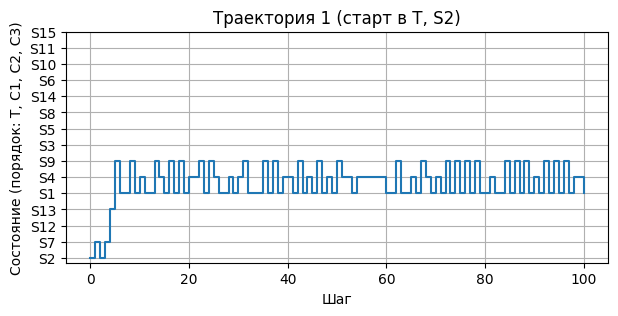

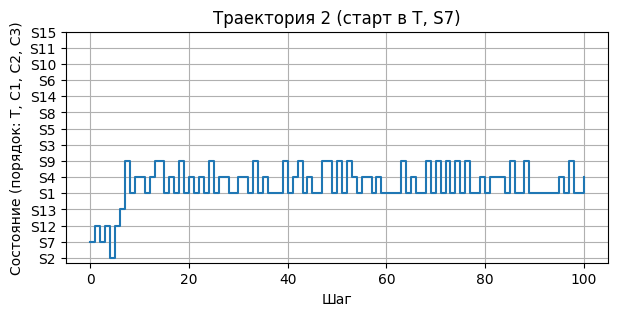

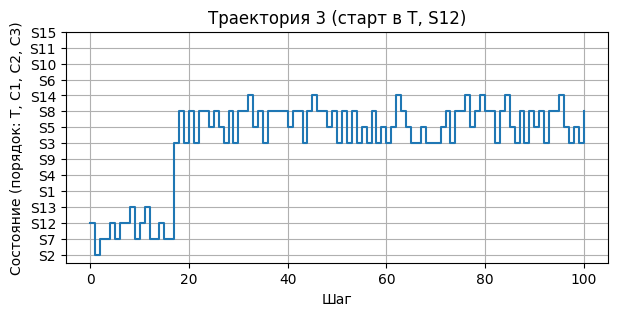

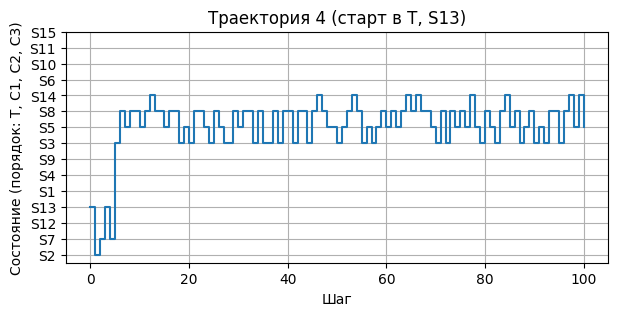

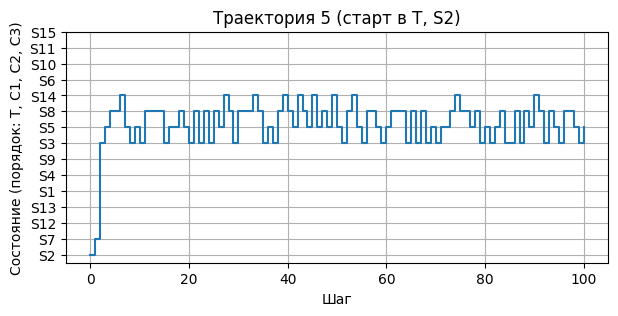

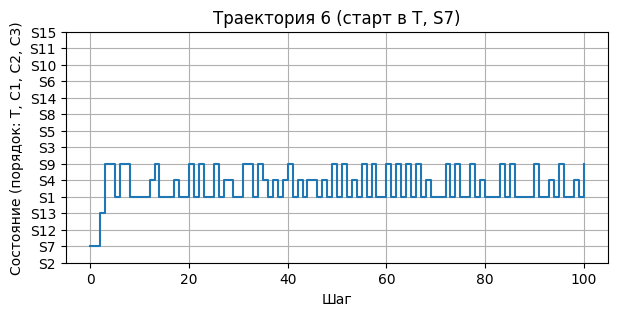

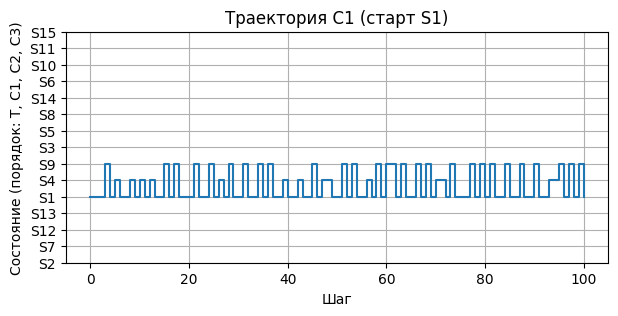

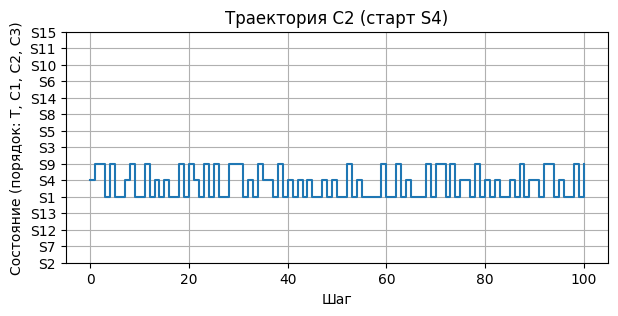

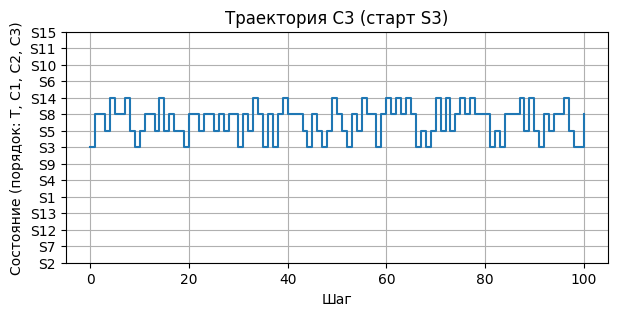

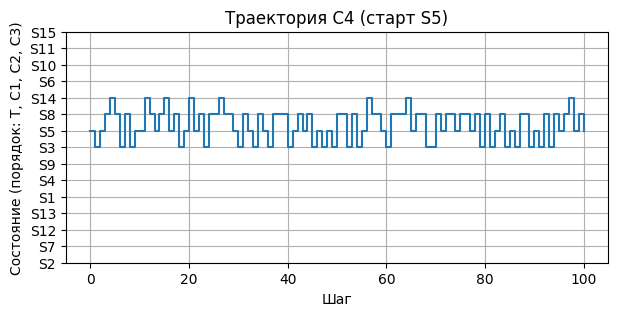

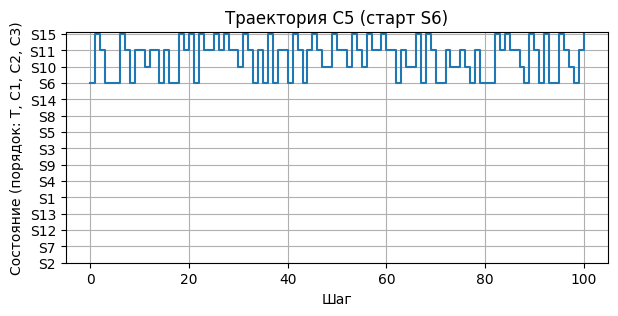

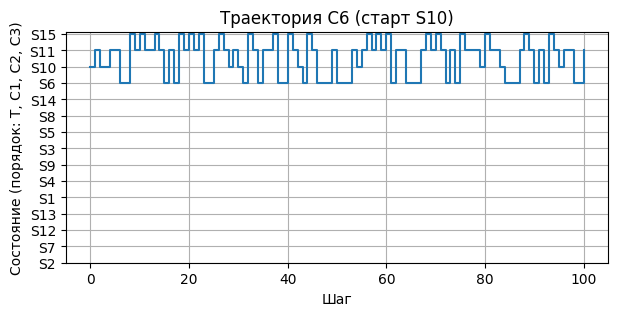

In [20]:
def plot_trajectory_reordered(traj, title):
    """Рисуем траекторию в НОВОЙ нумерации (T, затем C1, C2, C3).

    По оси Y — индексы new = inv_perm[old], чтобы классы шли блоками.
    Подписями оставляем исходные номера S1..S15 для удобства.
    """
    # old (0-based) -> new (0-based)
    new_traj = inv_perm[traj]

    plt.figure(figsize=(7, 3))
    plt.plot(new_traj, drawstyle="steps-post")

    # Подписи: показываем старые имена состояний в порядке новой нумерации
    y_positions = np.arange(n)
    y_labels = [f"S{old+1}" for old in perm_old]
    plt.yticks(y_positions, y_labels)

    plt.xlabel("Шаг")
    plt.ylabel("Состояние (порядок: T, C1, C2, C3)")
    plt.title(title)
    plt.grid(True)
    plt.show()

# 6 траекторий из несущественного класса T = {2,7,12,13}
starts_T = [1, 6, 11, 12, 1, 6]  # индексы 0-базные (старые номера)
for idx, s0 in enumerate(starts_T, 1):
    traj = simulate_chain(P, s0, n_steps, rng)
    plot_trajectory_reordered(traj, f"Траектория {idx} (старт в T, S{s0+1})")

# По 2 траектории из каждого существенного класса
starts_C = [0, 3,   # класс C1: 1,4
            2, 4,   # класс C2: 3,5
            5, 9]   # класс C3: 6,10

for idx, s0 in enumerate(starts_C, 1):
    traj = simulate_chain(P, s0, n_steps, rng)
    plot_trajectory_reordered(traj, f"Траектория C{idx} (старт S{s0+1})")